# 01 — EDA: CBC, Glucose, HbA1c, Diabetes Diagnosis & Demographics

**Project:** Lab Test Recommendation System — predicting glucose/diabetes risk from CBC + demographics
**Workstream:** feeds *1. Project / Need Statement* and *3. Failure Modes + Analysis* (see `Team_Workstream_Plan.xlsx`)

This notebook starts with the five NHANES files that are directly relevant to the research
question (the rest of `data/raw/laboratory/` is not used here):

| File | Component | Why it matters |
|---|---|---|
| `DEMO_L` | Demographics | age, sex, etc. — the non-CBC predictors, and the full-sample base for merging |
| `CBC_L` | Complete Blood Count | the candidate predictor panel |
| `GLU_L` | Fasting Plasma Glucose | one candidate definition of "abnormal glycemic status" (fasting subsample only) |
| `GHB_L` | Glycohemoglobin (HbA1c) | a second candidate definition (larger subsample than fasting glucose) |
| `DIQ_L` | Diabetes Questionnaire | self-reported diagnosis — a third candidate definition, full sample |

All files share the respondent id **`SEQN`**. Goal of this notebook: merge them, understand how much
usable data we actually have under each possible label definition, and get a first look at how the
CBC predictors relate to glycemic status — before committing to one label definition (see the
"Known Uncertainties" section of the project README).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("..") / "data" / "raw"


## 1. Load the five core files

In [2]:
demo = pd.read_sas(DATA_DIR / "DEMO_L.xpt", format="xport")
cbc  = pd.read_sas(DATA_DIR / "CBC_L.xpt",  format="xport")
glu  = pd.read_sas(DATA_DIR / "GLU_L.xpt",  format="xport")
ghb  = pd.read_sas(DATA_DIR / "GHB_L.xpt",  format="xport")
diq  = pd.read_sas(DATA_DIR / "DIQ_L.xpt",  format="xport")

for name, df in [("DEMO", demo), ("CBC", cbc), ("GLU", glu), ("GHB", ghb), ("DIQ", diq)]:
    print(f"{name:5s} shape={df.shape}  SEQN unique={df['SEQN'].nunique() == len(df)}")


DEMO  shape=(11933, 27)  SEQN unique=True
CBC   shape=(8727, 23)  SEQN unique=True
GLU   shape=(3996, 4)  SEQN unique=True
GHB   shape=(7199, 3)  SEQN unique=True
DIQ   shape=(11744, 9)  SEQN unique=True


## 2. Keep only the columns we plan to use

Full variable labels are in the matching `*_L.htm` codebook next to each `.xpt` file in
`data/raw/`. Keeping a narrow set here makes the merged table easier to read; nothing is
deleted from the source files.


In [3]:
demo_cols = {
    "SEQN": "SEQN",
    "RIAGENDR": "sex",          # 1 = Male, 2 = Female
    "RIDAGEYR": "age_years",
    "RIDRETH3": "race_eth",     # race/Hispanic origin w/ NH Asian category
    "DMDEDUC2": "education",    # adults 20+
    "INDFMPIR": "income_pir",   # ratio of family income to poverty line
}
cbc_cols = {
    "SEQN": "SEQN",
    "LBXWBCSI": "wbc",          # 1000 cells/uL
    "LBXLYPCT": "lymph_pct",
    "LBXMOPCT": "mono_pct",
    "LBXNEPCT": "neut_pct",
    "LBXEOPCT": "eos_pct",
    "LBXBAPCT": "baso_pct",
    "LBXRBCSI": "rbc",          # million cells/uL
    "LBXHGB":   "hemoglobin",   # g/dL
    "LBXHCT":   "hematocrit",   # %
    "LBXMCVSI": "mcv",          # fL
    "LBXMCHSI": "mch",          # pg
    "LBXMC":    "mchc",         # g/dL
    "LBXRDW":   "rdw",          # %
    "LBXPLTSI": "platelet",     # 1000 cells/uL
    "LBXMPSI":  "mpv",          # fL
}
glu_cols = {"SEQN": "SEQN", "LBXGLU": "fasting_glucose_mgdl"}
ghb_cols = {"SEQN": "SEQN", "LBXGH": "hba1c_pct"}
diq_cols = {"SEQN": "SEQN", "DIQ010": "dx_diabetes"}  # 1=Yes, 2=No, 3=Borderline/prediabetes, 7/9=Refused/DK

demo_s = demo[list(demo_cols)].rename(columns=demo_cols)
cbc_s  = cbc[list(cbc_cols)].rename(columns=cbc_cols)
glu_s  = glu[list(glu_cols)].rename(columns=glu_cols)
ghb_s  = ghb[list(ghb_cols)].rename(columns=ghb_cols)
diq_s  = diq[list(diq_cols)].rename(columns=diq_cols)


## 3. Merge on `SEQN`

`DEMO` is the full examined sample, so we left-merge everything onto it. `GLU` (fasting glucose)
is only collected on a random fasting subsample — expect a lot of missingness there, which is
exactly the constraint the README flags under "Known Uncertainties".


In [4]:
df = (
    demo_s
    .merge(cbc_s, on="SEQN", how="left")
    .merge(glu_s, on="SEQN", how="left")
    .merge(ghb_s, on="SEQN", how="left")
    .merge(diq_s, on="SEQN", how="left")
)
print(df.shape)
df.head()


(11933, 24)


,SEQN,sex,age_years,race_eth,education,income_pir,wbc,lymph_pct,mono_pct,neut_pct,eos_pct,baso_pct,rbc,hemoglobin,hematocrit,mcv,mch,mchc,rdw,platelet,mpv,fasting_glucose_mgdl,hba1c_pct,dx_diabetes
0,130378.0,1.0,43.0,6.0,5.0,5.00,4.7,40.8,6.8,46.1,5.2,1.2,5.19,15.7,45.3,87.4,30.2,34.6,12.9,259.0,7.8,113.0,5.6,2.0
1,130379.0,1.0,66.0,3.0,5.0,5.00,6.3,25.4,14.2,57.3,2.5,0.7,4.59,15.2,43.9,95.8,33.0,34.5,12.8,221.0,8.5,99.0,5.6,2.0
2,130380.0,2.0,44.0,2.0,3.0,1.41,5.7,29.9,5.5,58.5,5.3,0.9,4.86,13.8,40.1,82.5,28.3,34.4,13.3,235.0,9.1,156.0,6.2,1.0
3,130381.0,2.0,5.0,7.0,NaN,1.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
4,130382.0,1.0,2.0,3.0,NaN,3.60,11.4,29.9,8.3,60.1,1.2,0.6,4.61,12.3,36.5,79.2,26.7,33.6,14.6,342.0,7.4,NaN,NaN,2.0


## 4. How much usable data do we actually have?

In [5]:
n_total = len(df)
coverage = pd.DataFrame({
    "n_available": [
        df["wbc"].notna().sum(),
        df["fasting_glucose_mgdl"].notna().sum(),
        df["hba1c_pct"].notna().sum(),
        df["dx_diabetes"].isin([1, 2, 3]).sum(),
    ],
}, index=["CBC panel", "Fasting glucose", "HbA1c", "Self-reported diabetes (valid answer)"])
coverage["pct_of_full_sample"] = (coverage["n_available"] / n_total * 100).round(1)
coverage


,n_available,pct_of_full_sample
CBC panel,7593,63.6
Fasting glucose,3672,30.8
HbA1c,6715,56.3
Self-reported diabetes (valid answer),11736,98.3


In [6]:
has_cbc = df["wbc"].notna()
label_coverage = pd.DataFrame({
    "n_with_CBC_and_label": [
        (has_cbc & df["fasting_glucose_mgdl"].notna()).sum(),
        (has_cbc & df["hba1c_pct"].notna()).sum(),
        (has_cbc & df["dx_diabetes"].isin([1, 2, 3])).sum(),
    ],
}, index=["CBC + fasting glucose", "CBC + HbA1c", "CBC + self-reported diabetes"])
label_coverage


,n_with_CBC_and_label
CBC + fasting glucose,3657
CBC + HbA1c,6689
CBC + self-reported diabetes,7592


**Takeaway:** the usable sample size depends heavily on which outcome definition the team picks
(fasting glucose vs. HbA1c vs. self-report) — this is the "target definition" decision called out
in the README and directly affects *3. Failure Modes + Analysis* (a smaller usable sample raises
the risk of an underpowered/unstable model).


## 5. Demographics of the merged sample

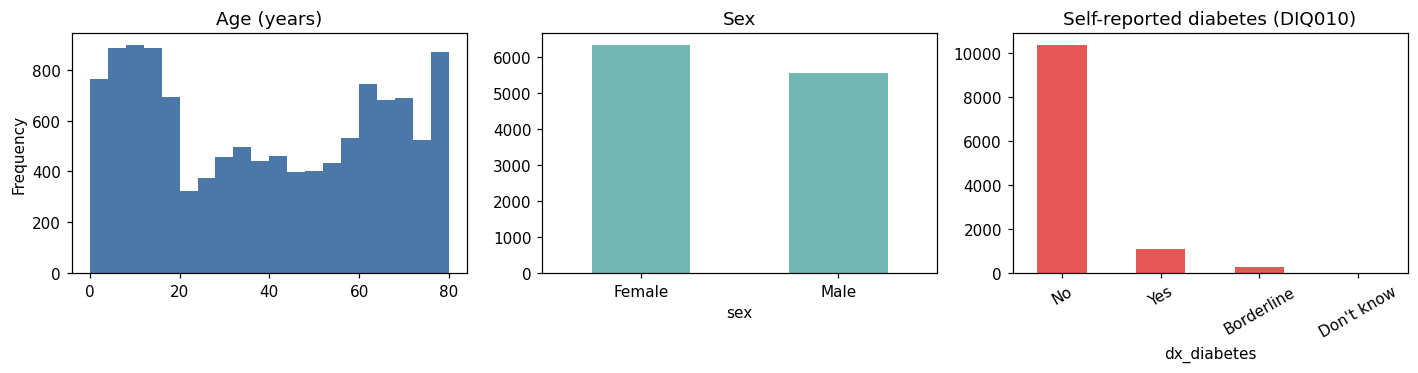

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

df["age_years"].plot(kind="hist", bins=20, ax=axes[0], color="#4C78A8")
axes[0].set_title("Age (years)")

df["sex"].map({1: "Male", 2: "Female"}).value_counts().plot(kind="bar", ax=axes[1], color="#72B7B2")
axes[1].set_title("Sex")
axes[1].tick_params(axis="x", rotation=0)

df["dx_diabetes"].map({1: "Yes", 2: "No", 3: "Borderline", 7: "Refused", 9: "Don't know"}).value_counts().plot(
    kind="bar", ax=axes[2], color="#E45756"
)
axes[2].set_title("Self-reported diabetes (DIQ010)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 6. CBC predictor distributions

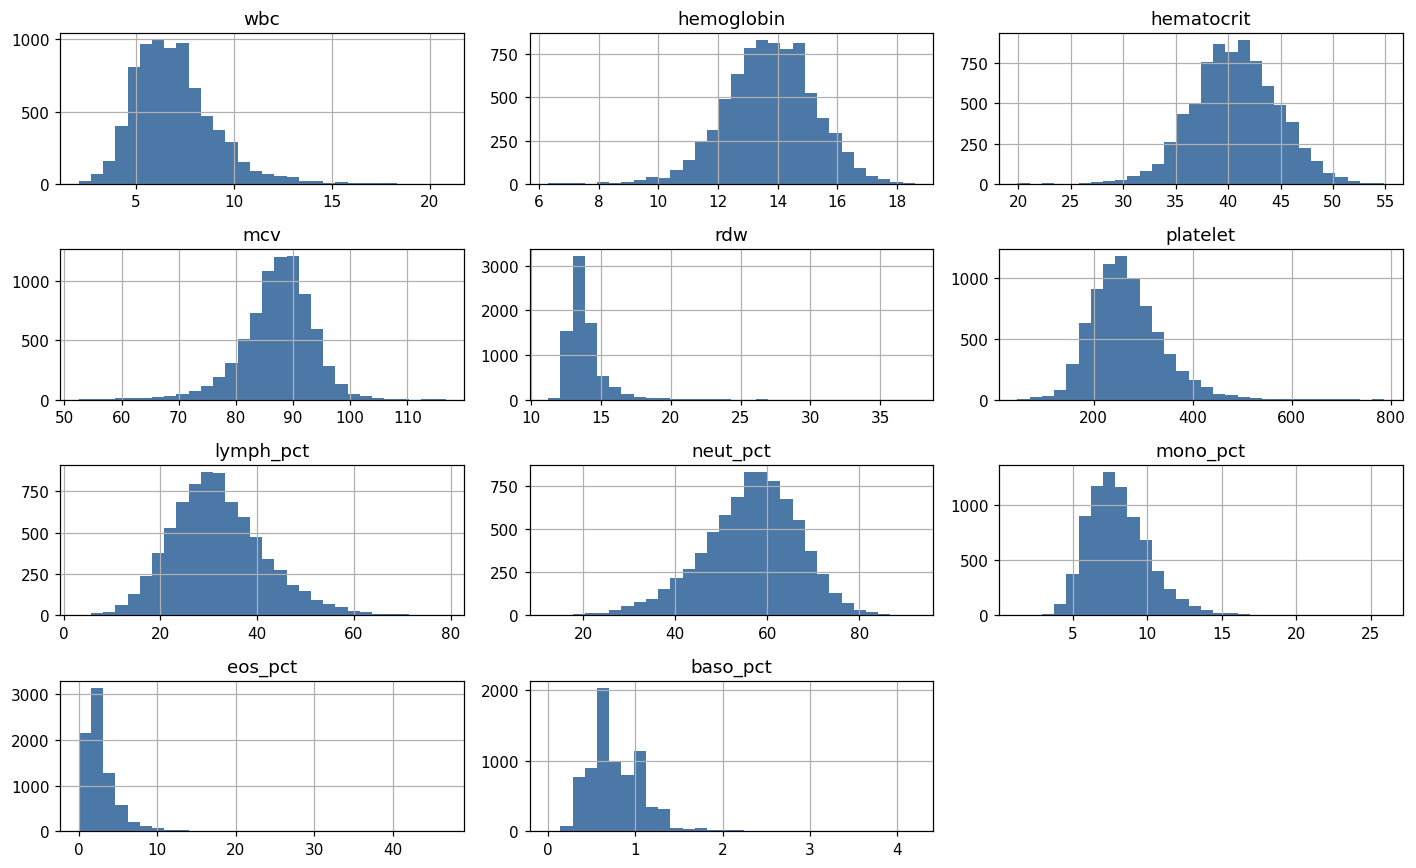

In [8]:
cbc_vars = ["wbc", "hemoglobin", "hematocrit", "mcv", "rdw", "platelet",
            "lymph_pct", "neut_pct", "mono_pct", "eos_pct", "baso_pct"]

axes = df[cbc_vars].hist(bins=30, figsize=(13, 8), color="#4C78A8")
plt.tight_layout()
plt.show()


## 7. Glycemic outcome distributions

Fasting glucose and HbA1c are plotted with the standard clinical cut-points so the shape of
"normal vs. abnormal" is visible before any label is finalized:
- Fasting glucose: <100 normal, 100–125 prediabetes, ≥126 diabetes (mg/dL)
- HbA1c: <5.7% normal, 5.7–6.4% prediabetes, ≥6.5% diabetes


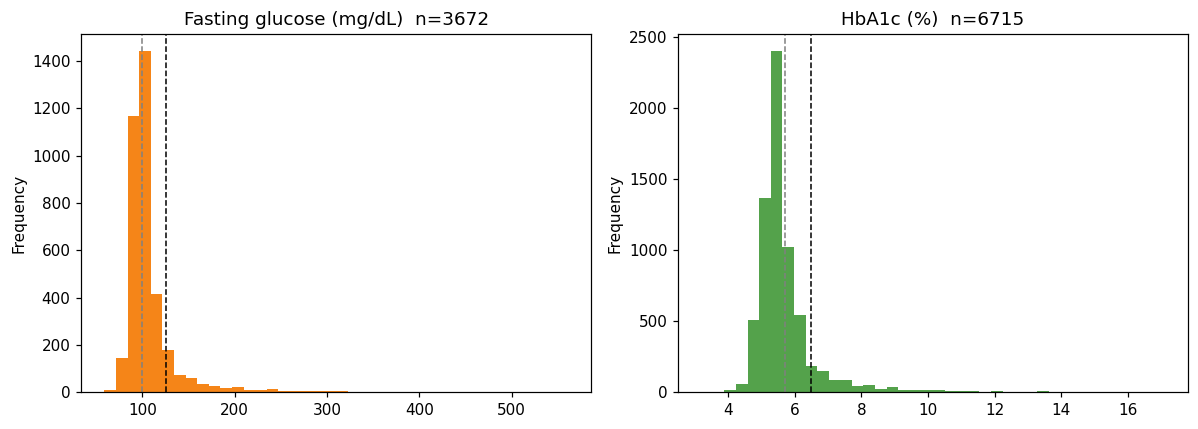

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["fasting_glucose_mgdl"].plot(kind="hist", bins=40, ax=axes[0], color="#F58518")
axes[0].axvline(100, color="gray", linestyle="--", linewidth=1)
axes[0].axvline(126, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Fasting glucose (mg/dL)  n={df['fasting_glucose_mgdl'].notna().sum()}")

df["hba1c_pct"].plot(kind="hist", bins=40, ax=axes[1], color="#54A24B")
axes[1].axvline(5.7, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(6.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"HbA1c (%)  n={df['hba1c_pct'].notna().sum()}")

plt.tight_layout()
plt.show()


## 8. Exploratory label comparison (not a final decision)

Just to see how the three candidate outcome definitions compare — this is exploratory only; the
team still needs to decide and justify one definition (see README "Known Uncertainties").


In [10]:
abnormal_glucose = df["fasting_glucose_mgdl"] >= 126
abnormal_hba1c = df["hba1c_pct"] >= 6.5
self_report_yes = df["dx_diabetes"] == 1

exploratory_labels = pd.DataFrame({
    "definition": ["Fasting glucose >= 126", "HbA1c >= 6.5%", "Self-reported diagnosis"],
    "n_available": [df["fasting_glucose_mgdl"].notna().sum(),
                     df["hba1c_pct"].notna().sum(),
                     self_report_yes.notna().sum()],
    "n_flagged_abnormal": [abnormal_glucose.sum(), abnormal_hba1c.sum(), self_report_yes.sum()],
})
exploratory_labels["pct_abnormal"] = (
    exploratory_labels["n_flagged_abnormal"] / exploratory_labels["n_available"] * 100
).round(1)
exploratory_labels


,definition,n_available,n_flagged_abnormal,pct_abnormal
0,Fasting glucose >= 126,3672,430,11.7
1,HbA1c >= 6.5%,6715,721,10.7
2,Self-reported diagnosis,11933,1081,9.1


## 9. CBC predictors vs. glycemic status (first look)

Using HbA1c as the exploratory label here since it has the largest usable sample of the two lab
measures. This is a quick first look, not a final model.


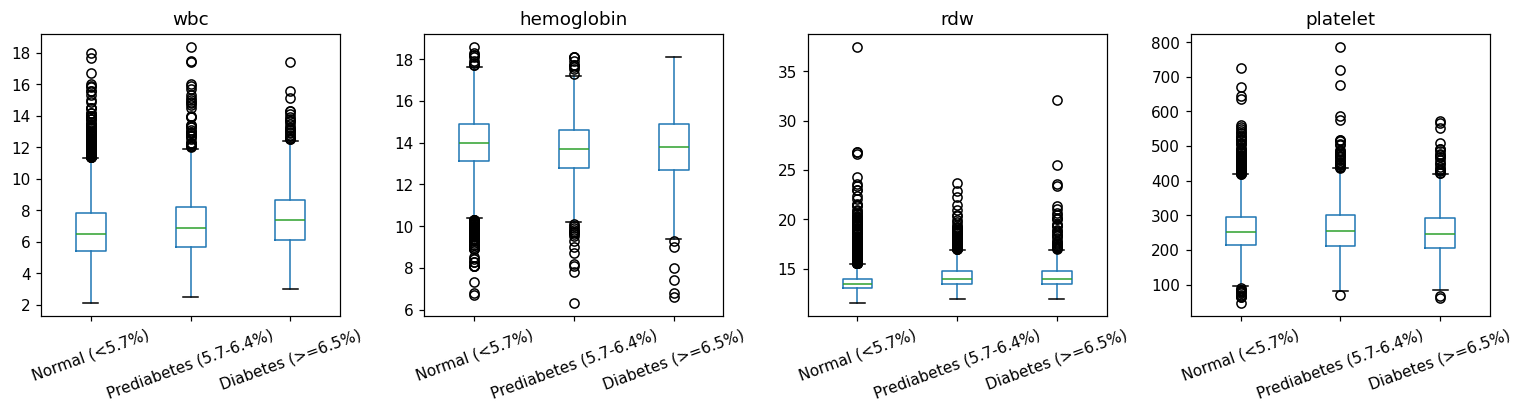

In [11]:
status = pd.cut(
    df["hba1c_pct"], bins=[0, 5.7, 6.5, 100],
    labels=["Normal (<5.7%)", "Prediabetes (5.7-6.4%)", "Diabetes (>=6.5%)"],
)

plot_vars = ["wbc", "hemoglobin", "rdw", "platelet"]
fig, axes = plt.subplots(1, len(plot_vars), figsize=(14, 4))
for ax, var in zip(axes, plot_vars):
    df.assign(hba1c_status=status).boxplot(column=var, by="hba1c_status", ax=ax, grid=False)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("")
plt.tight_layout()
plt.show()


In [12]:
df.assign(hba1c_status=status).groupby("hba1c_status", observed=True)[cbc_vars].mean().round(2)


,wbc,hemoglobin,hematocrit,mcv,rdw,platelet,lymph_pct,neut_pct,mono_pct,eos_pct,baso_pct
hba1c_status,,,,,,,,,,,
Normal (<5.7%),6.74,13.93,41.15,88.39,13.66,258.44,30.83,57.77,8.05,2.68,0.79
Prediabetes (5.7-6.4%),7.15,13.67,40.83,87.73,14.29,263.22,30.21,57.99,8.23,2.86,0.84
Diabetes (>=6.5%),7.57,13.75,41.01,87.26,14.33,252.58,29.31,59.43,7.81,2.75,0.83


## 10. Missingness summary

Relevant for *3. Failure Modes + Analysis* — missing-data patterns (e.g., whether CBC is more
often missing for certain demographic groups) are themselves a potential failure mode / bias
risk for the final recommendation system.


In [13]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(1).to_frame("pct_missing")


,pct_missing
fasting_glucose_mgdl,69.2
hba1c_pct,43.7
neut_pct,36.5
lymph_pct,36.5
mono_pct,36.5
eos_pct,36.5
baso_pct,36.5
hemoglobin,36.4
mchc,36.4
mch,36.4


## Descriptive statistics

- Fasting glucose and HbA1c were strongly right-skewed, with most observations in the lower ranges and relatively few very high values. HbA1c was available for 6,715 participants, compared with 3,672 for fasting glucose.
- The 11,933-participant sample covered ages 0–80 and was approximately balanced by sex (46.7% male, 53.3% female). Most participants with a valid diabetes-status response reported no previous diagnosis.
- Hemoglobin and hematocrit were approximately symmetric; MCV showed mild left skew. WBC, RDW, platelet count, eosinophil percentage, and basophil percentage were right-skewed and had high-end extreme values.
- Median WBC increased across normal, prediabetes, and diabetes HbA1c categories (6.5, 6.9, and 7.4). Median RDW rose from normal to prediabetes (13.4 to 14.0) and remained at 14.0 in the diabetes category. Hemoglobin and platelet distributions showed comparatively little separation, with substantial overlap across categories for all four CBC measurements.

### Missing data

Fasting glucose was missing for 69.2% of the full sample, the largest missing proportion among the merged variables. Raw missingness for self-reported diabetes status was lowest at 1.6%; counting the four coded "don't know" responses as unavailable brings that figure to 1.7%. Glucose availability is constrained by NHANES eligibility (age 12 and older), its fasting-subsample design, and specimen/fasting criteria, so missingness alone should not be interpreted as poor data quality. Fasting-glucose analyses will use participants with available outcome measurements and compare that analytical sample with the full sample. Formal analyses should use the fasting-subsample weight and account for the NHANES survey design.

## Next steps

- **Literature review (Ahenkan)**: use the fasting-glucose / HbA1c / self-report coverage numbers
  above to motivate the label-definition discussion, alongside how existing studies define their
  outcome.
- **Project / Need Statement (Hamid)**: cite the usable-sample-size trade-off (Section 4) directly
  in the need statement's scoping.
- **Failure Modes + Analysis (Hamid / Ahenkan)**: the missingness pattern (Section 10) and the
  smaller fasting-glucose subsample are candidate failure modes to formalize.
- Once a label definition is chosen, add a `02_label_definition.ipynb` and, after that, modeling
  notebooks (`sklearn` and `seaborn` aren't installed yet — add them when that work starts).
